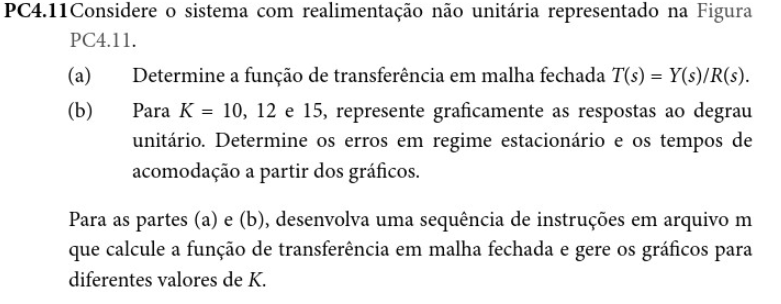
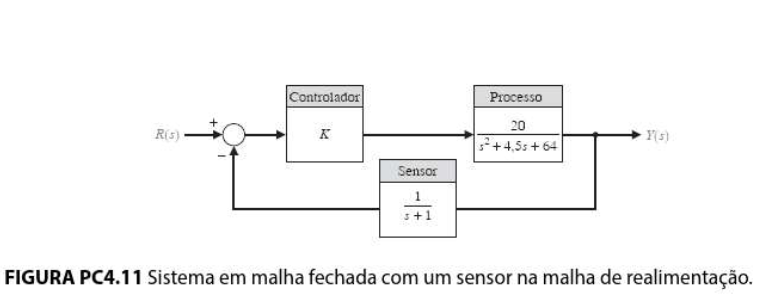

PROBLEMA PC4.11 - ANÁLISE DO SISTEMA DE CONTROLE

(a) FUNÇÃO DE TRANSFERÊNCIA EM MALHA FECHADA


Para K = 10:
T(s) = Y(s)/R(s) =
<TransferFunction>: sys[4]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

          200 s + 200
  ----------------------------
  s^3 + 5.5 s^2 + 10.5 s + 206

Numerador: [200. 200.]
Denominador: [array([  1. ,   5.5,  10.5, 206. ])]

Para K = 12:
T(s) = Y(s)/R(s) =
<TransferFunction>: sys[9]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

          240 s + 240
  ----------------------------
  s^3 + 5.5 s^2 + 10.5 s + 246

Numerador: [240. 240.]
Denominador: [array([  1. ,   5.5,  10.5, 246. ])]

Para K = 15:
T(s) = Y(s)/R(s) =
<TransferFunction>: sys[14]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

          300 s + 300
  ----------------------------
  s^3 + 5.5 s^2 + 10.5 s + 306

Numerador: [300. 300.]
Denominador: [array([  1. ,   5.5,  10.5, 306. ])]

(b) RESPOSTA AO DEGRAU UNITÁRIO E ANÁLISE

─────────────────────────────────────────────────────────────────
K = 

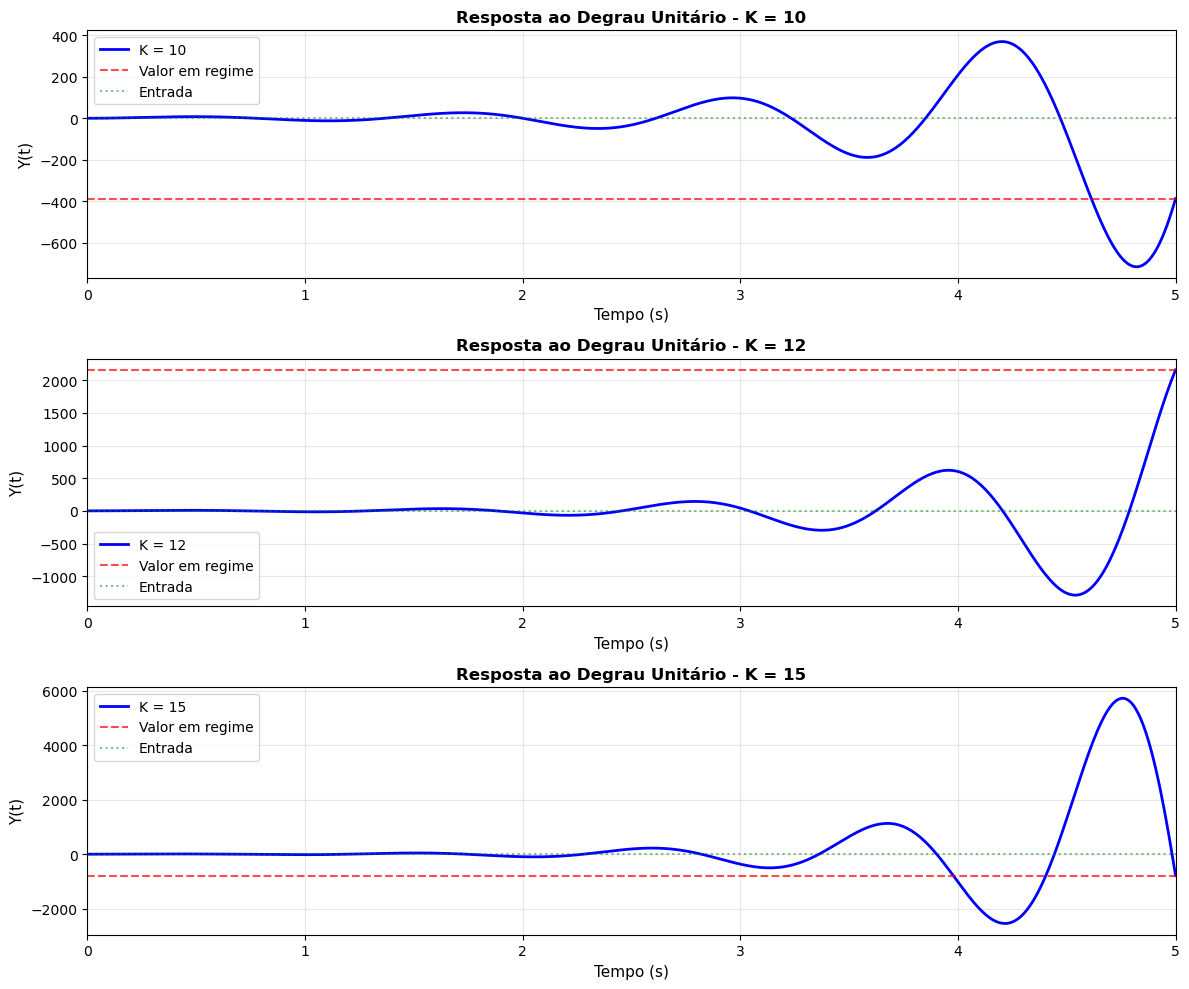


Gráfico salvo como 'step_response_analysis.png'


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import control as ct
from scipy import signal

# Define the system components
# Process: G_p(s) = 20/(s^2 + 4.5s + 6)
# Sensor: H(s) = 1/(s+1)
# Controller: K (gain)

# Numerator and denominator of the process
num_process = [20]
den_process = [1, 4.5, 6]

# Numerator and denominator of the sensor
num_sensor = [1]
den_sensor = [1, 1]

# Define K values
K_values = [10, 12, 15]

# Function to calculate closed-loop transfer function
def calculate_closed_loop_tf(K):
    """
    Calculate T(s) = Y(s)/R(s) for the closed-loop system
    Forward path: G(s) = K * 20/(s^2 + 4.5s + 6)
    Feedback: H(s) = 1/(s+1)
    """
    # Create transfer functions
    G_p = ct.TransferFunction(num_process, den_process)  # Process
    H = ct.TransferFunction(num_sensor, den_sensor)      # Sensor
    
    # Forward path transfer function
    G = K * G_p
    
    # Closed-loop transfer function: T(s) = G/(1 + G*H)
    T = ct.feedback(G, H)
    
    return T

# Calculate transfer functions and analyze for each K
print("=" * 70)
print("PROBLEMA PC4.11 - ANÁLISE DO SISTEMA DE CONTROLE")
print("=" * 70)
print("\n(a) FUNÇÃO DE TRANSFERÊNCIA EM MALHA FECHADA\n")

transfer_functions = {}
for K in K_values:
    T = calculate_closed_loop_tf(K)
    transfer_functions[K] = T
    print(f"\nPara K = {K}:")
    print(f"T(s) = Y(s)/R(s) =")
    print(T)
    
    # Extract numerator and denominator
    num, den = ct.tfdata(T)
    num = num[0][0]  # Extract from nested array
    den = den[0]     # Extract from nested array
    print(f"\nNumerador: {num}")
    print(f"Denominador: {den}")

# Part (b): Plot step response and analyze
print("\n" + "=" * 70)
print("(b) RESPOSTA AO DEGRAU UNITÁRIO E ANÁLISE")
print("=" * 70)

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

for idx, K in enumerate(K_values):
    T = transfer_functions[K]
    
    # Calculate step response
    t, y = ct.step_response(T, T=np.linspace(0, 5, 500))
    
    # Calculate steady-state error for unit step
    steady_state_value = y[-1]
    steady_state_error = 1 - steady_state_value
    
    # Calculate settling time (2% criterion)
    settling_time = None
    tolerance = 0.02  # 2%
    for i in range(len(y) - 1, 0, -1):
        if abs(y[i] - steady_state_value) > tolerance * steady_state_value:
            settling_time = t[i]
            break
    
    # Calculate rise time (10% to 90%)
    y_10 = 0.1 * steady_state_value
    y_90 = 0.9 * steady_state_value
    rise_time = None
    cross_90 = None
    for i in range(len(y)):
        if rise_time is None and y[i] >= y_10:
            rise_time_start = t[i]
        if y[i] >= y_90:
            cross_90 = t[i]
            if rise_time is None:
                rise_time = cross_90 - (t[i-1] if i > 0 else 0)
            break
    
    # Find overshoot
    max_overshoot = max(y) - steady_state_value
    percent_overshoot = (max_overshoot / steady_state_value) * 100 if steady_state_value > 0 else 0
    
    # Plot
    axes[idx].plot(t, y, 'b-', linewidth=2, label=f'K = {K}')
    axes[idx].axhline(y=steady_state_value, color='r', linestyle='--', alpha=0.7, label='Valor em regime')
    axes[idx].axhline(y=1, color='g', linestyle=':', alpha=0.5, label='Entrada')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_xlabel('Tempo (s)', fontsize=11)
    axes[idx].set_ylabel('Y(t)', fontsize=11)
    axes[idx].set_title(f'Resposta ao Degrau Unitário - K = {K}', fontsize=12, fontweight='bold')
    axes[idx].legend(fontsize=10)
    axes[idx].set_xlim(0, 5)
    
    # Display analysis
    print(f"\n{'─' * 65}")
    print(f"K = {K}")
    print(f"{'─' * 65}")
    print(f"  Valor em regime estacionário (Y_ss):     {steady_state_value:.6f}")
    print(f"  Erro em regime estacionário (e_ss):      {steady_state_error:.6f}")
    print(f"  Percentual de ultrapassagem (overshoot): {percent_overshoot:.2f}%")
    if settling_time:
        print(f"  Tempo de acomodação (2%):                {settling_time:.4f} s")
    else:
        print(f"  Tempo de acomodação (2%):                > 5 s")
    if cross_90:
        print(f"  Tempo até 90% do valor final:            {cross_90:.4f} s")

plt.tight_layout()
plt.savefig('step_response_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 70)
print("Gráfico salvo como 'step_response_analysis.png'")
print("=" * 70)